# 09 3-Period Pricing Extension

This notebook demonstrates a **fixed 3-period** pricing extension with a shared feature-price structure,
shared segment identities, and **period-varying demand** introduced through segment **weight shifts**.

Modeling choice:
- shared segment catalog across all 3 periods
- period-varying demand through weight shifts, not new segment identities
- shared horizon inventory with carryover from period to period
- static vs dynamic pricing comparison only
- no DQI integration in this phase


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT_HINT = Path.cwd().resolve()
if (ROOT_HINT / "src").is_dir():
    REPO_ROOT = ROOT_HINT
elif (ROOT_HINT.parent / "src").is_dir():
    REPO_ROOT = ROOT_HINT.parent
else:
    REPO_ROOT = ROOT_HINT
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from notebooks._helpers import repo_root
except ModuleNotFoundError:
    from _helpers import repo_root

from src.classical_baselines_multiperiod import (
    build_multiperiod_scenario_matrix,
    make_multiperiod_scenario_problem,
)

ROOT = repo_root()
RESULTS_TABLE_DIR = ROOT / "results" / "tables"
RESULTS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
SCENARIO_MATRIX_EXPORT_PATH = ROOT / "results" / "tables" / "3period_scenario_matrix.csv"
pd.set_option("display.max_colwidth", 120)


In [2]:
scenario_rows = build_multiperiod_scenario_matrix()
scenario_matrix_df = pd.DataFrame(scenario_rows)
scenario_matrix_path = SCENARIO_MATRIX_EXPORT_PATH
scenario_matrix_df.to_csv(scenario_matrix_path, index=False)

comparison_df = scenario_matrix_df[
    [
        "scenario_label",
        "dynamic_horizon_revenue",
        "static_horizon_revenue",
        "static_vs_dynamic_delta",
        "remaining_inventory",
        "inventory_usage_summary",
        "dynamic_changes_across_periods",
        "delta_reduction_vs_zero_smoothing",
        "choices_change_vs_zero_smoothing",
    ]
].copy()

verdict_df = scenario_matrix_df[
    [
        "scenario_label",
        "dynamic_horizon_revenue",
        "static_horizon_revenue",
        "static_vs_dynamic_delta",
        "inventory_used",
        "dynamic_changes_across_periods",
        "verdict",
    ]
].copy()
verdict_df = verdict_df.rename(
    columns={
        "dynamic_horizon_revenue": "dynamic_revenue",
        "static_horizon_revenue": "static_revenue",
        "static_vs_dynamic_delta": "delta",
        "dynamic_changes_across_periods": "package_changed_across_periods",
    }
)

display(comparison_df)
display(pd.DataFrame([
    {
        "artifact": scenario_matrix_path.name,
        "rows_exported": len(scenario_matrix_df),
        "path": str(scenario_matrix_path.relative_to(ROOT)),
    }
]))

,scenario_label,dynamic_horizon_revenue,static_horizon_revenue,static_vs_dynamic_delta,remaining_inventory,inventory_usage_summary,dynamic_changes_across_periods,delta_reduction_vs_zero_smoothing,choices_change_vs_zero_smoothing
0,low-tight-smooth-0,2100.0,2100.0,0.0,2,"used [0, 0, 0] -> remaining [2, 2, 2]",False,0.0,False
1,low-buffered-smooth-5,2100.0,2100.0,0.0,3,"used [0, 0, 0] -> remaining [3, 3, 3]",False,0.0,False
2,medium-tight-smooth-0,2104.0,2086.0,18.0,1,"used [0, 0, 1] -> remaining [2, 2, 1]",True,0.0,False
3,medium-tight-smooth-20,2086.0,2086.0,0.0,2,"used [0, 0, 0] -> remaining [2, 2, 2]",False,18.0,True
4,medium-buffered-smooth-0,2104.0,2086.0,18.0,2,"used [0, 0, 1] -> remaining [3, 3, 2]",True,0.0,False
5,medium-loose-smooth-5,2099.0,2086.0,13.0,2,"used [0, 0, 2] -> remaining [4, 4, 2]",True,5.0,True
6,high-tight-smooth-0,2236.0,2086.0,150.0,1,"used [0, 0, 1] -> remaining [2, 2, 1]",True,0.0,False
7,high-tight-smooth-5,2231.0,2086.0,145.0,1,"used [0, 0, 1] -> remaining [2, 2, 1]",True,5.0,False
8,high-buffered-smooth-20,2216.0,2086.0,130.0,2,"used [0, 0, 1] -> remaining [3, 3, 2]",True,20.0,False


,artifact,rows_exported,path
0,3period_scenario_matrix.csv,9,results/tables/3period_scenario_matrix.csv


In [3]:
representative_prob = make_multiperiod_scenario_problem(
    demand_shift="medium",
    inventory_regime="buffered",
    smoothing_penalty=5.0,
)

instance_summary_df = pd.DataFrame([
    {
        "n_periods": representative_prob.n_periods,
        "n_configurations": representative_prob.n_configurations,
        "initial_inventory": representative_prob.initial_inventory,
        "per_period_capacity_caps": representative_prob.per_period_capacity_caps,
        "smoothing_penalty": representative_prob.smoothing_penalty,
    }
])
weight_shift_df = pd.DataFrame(
    {
        "period": [0, 1, 2],
        "budget_weight_shift": representative_prob.period_segment_multipliers[:, 0],
        "premium_weight_shift": representative_prob.period_segment_multipliers[:, 1],
    }
)
coverage_df = scenario_matrix_df[["demand_shift", "inventory_regime", "smoothing_penalty"]].copy()

display(instance_summary_df)
display(weight_shift_df)
display(coverage_df)
display(verdict_df)


,n_periods,n_configurations,initial_inventory,per_period_capacity_caps,smoothing_penalty
0,3,16,3,"[2, 2, 2]",5.0


,period,budget_weight_shift,premium_weight_shift
0,0,1.0,1.0
1,1,1.2,0.8
2,2,0.7,1.3


,demand_shift,inventory_regime,smoothing_penalty
0,low,tight,0.0
1,low,buffered,5.0
2,medium,tight,0.0
3,medium,tight,20.0
4,medium,buffered,0.0
5,medium,loose,5.0
6,high,tight,0.0
7,high,tight,5.0
8,high,buffered,20.0


,scenario_label,dynamic_revenue,static_revenue,delta,inventory_used,package_changed_across_periods,verdict
0,low-tight-smooth-0,2100.0,2100.0,0.0,0,False,near-static-match
1,low-buffered-smooth-5,2100.0,2100.0,0.0,0,False,near-static-match
2,medium-tight-smooth-0,2104.0,2086.0,18.0,1,True,dynamic-uplift-via-package-change
3,medium-tight-smooth-20,2086.0,2086.0,0.0,0,False,near-static-match
4,medium-buffered-smooth-0,2104.0,2086.0,18.0,1,True,dynamic-uplift-via-package-change
5,medium-loose-smooth-5,2099.0,2086.0,13.0,2,True,dynamic-uplift-via-package-change
6,high-tight-smooth-0,2236.0,2086.0,150.0,1,True,dynamic-uplift-via-package-change
7,high-tight-smooth-5,2231.0,2086.0,145.0,1,True,dynamic-uplift-via-package-change
8,high-buffered-smooth-20,2216.0,2086.0,130.0,1,True,dynamic-uplift-via-package-change


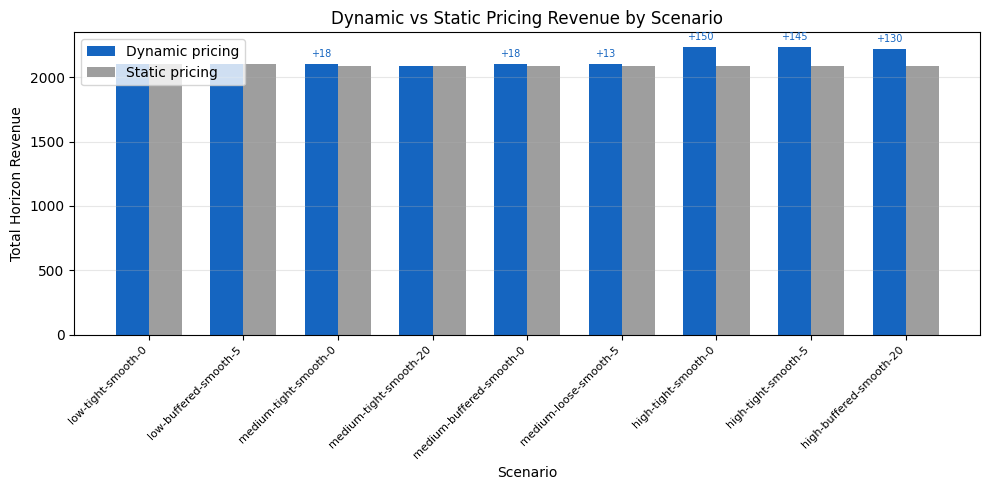

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(verdict_df))
width = 0.35

bars_dynamic = ax.bar(x - width/2, verdict_df["dynamic_revenue"], width, label="Dynamic pricing", color="#1565c0")
bars_static = ax.bar(x + width/2, verdict_df["static_revenue"], width, label="Static pricing", color="#9e9e9e")

ax.set_xlabel("Scenario")
ax.set_ylabel("Total Horizon Revenue")
ax.set_title("Dynamic vs Static Pricing Revenue by Scenario")
ax.set_xticks(x)
ax.set_xticklabels(verdict_df["scenario_label"], rotation=45, ha="right", fontsize=8)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Annotate deltas
for i, delta in enumerate(verdict_df["delta"]):
    if delta > 0:
        ax.annotate(f"+{delta:.0f}", xy=(x[i] - width/2, verdict_df["dynamic_revenue"].iloc[i]),
                    xytext=(0, 5), textcoords="offset points", ha="center", fontsize=7, color="#1565c0")

fig.tight_layout()
plt.show()

This is **dynamic-pricing-adjacent** because the chosen package configuration can change across periods as
demand shifts over the same shared segments while a **shared horizon inventory** is consumed over time.
The matrix is deliberately **selected for regime coverage and interpretability**, not to mostly maximize uplift,
and this notebook makes **no DQI integration** claim.

## Implementation Notes

### Static Baseline Convergence
The static baseline converges to the same revenue across multiple scenarios because:
1. Static pricing selects a single package configuration for the entire horizon
2. This selection is based on aggregate expected demand across all periods
3. When demand shifts are moderate (low/medium regimes), the static optimum often coincides with the dynamic per-period optimum
4. Higher demand shifts (high regime) create larger gaps where dynamic adaptation provides measurable uplift

### Solver Timing
The CP-SAT solver executes sub-millisecond for these small instances (2 segments x 3 periods x 16 configurations).
The `solve_time` fields may show 0.0 due to timer resolution limits, not solver failure. The solver is deterministic
and the results are validated by the verdict column which compares dynamic vs static outcomes.